<a href="https://colab.research.google.com/github/Marfall/CNN-Otus-6/blob/main/CNN_Otus_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №6: Классификация организации облаков

**Цель:** Построить свёрточную нейронную сеть (U-Net) для сегментации облачных структур на спутниковых снимках. Оценить качество с помощью Dice coefficient.

**Датасет:** Understanding Cloud Organization. 4 класса: Fish, Flower, Gravel, Sugar. Разметка — RLE в train.csv.

**План:**
1. Импорт библиотек и настройка окружения.
2. Seed, устройство.
3. Монтирование Drive, пути.
4. Разбор train.csv (RLE-разметка).
5. Формирование подвыборки.
6. EDA.
7. Dataset и DataLoader.
8. Архитектура U-Net.
9. Loss и метрика.
10. Обучение с ранней остановкой.
11. Графики и оценка.
12. Визуализация предсказаний.
13. Выводы.

## 1. Импорт библиотек и настройка окружения

Подключаем стандартный стек: PyTorch, NumPy, pandas для табличных сводок, Seaborn и Matplotlib для визуализации. Настраиваем единый стиль графиков.

In [42]:
# 2: Импорт библиотек и настройка стиля визуализации
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import shutil

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('PyTorch:', torch.__version__)
print('CUDA:', torch.cuda.is_available())

PyTorch: 2.11.0+cu128
CUDA: True


## 3. Фиксация seed и определение устройства

Фиксируем seed для numpy и torch — обеспечивает воспроизводимость результатов. Определяем устройство: GPU, если доступен, иначе CPU.

In [43]:
# 4: Фиксация seed и выбор устройства
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cuda
GPU: Tesla T4


## 5. Монтирование Google Drive и определение путей

Данные лежат на Google Drive. Работаем с подвыборкой в `/content` для скорости. Оригиналы остаются на Drive — не теряются при перезапуске сессии.

In [44]:
# 6: Монтирование Drive и определение путей
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/cloud_dhw/cloud_data'
TRAIN_IMGS_DRIVE = os.path.join(DRIVE_ROOT, 'train_images')
TRAIN_CSV = os.path.join(DRIVE_ROOT, 'train.csv')

print('train_images:', TRAIN_IMGS_DRIVE, '|', len(os.listdir(TRAIN_IMGS_DRIVE)), 'файлов')
print('train.csv существует:', os.path.exists(TRAIN_CSV))
print('Размер train.csv:', f'{os.path.getsize(TRAIN_CSV) / 1e6:.1f} МБ')

train_images: /content/drive/MyDrive/cloud_dhw/cloud_data/train_images | 4655 файлов
train.csv существует: True
Размер train.csv: 213.8 МБ


## 7. Разбор train.csv (RLE-разметка)

Формат таблицы: `Image_Label,EncodedPixels`. `Image_Label = filename.jpg_ClassName`. Если для класса нет маски — `EncodedPixels` пустой. Группируем по файлу → 4 канала на изображение.

Всего строк: 22184
          Image_Label                                      EncodedPixels
0    0011165.jpg_Fish  264918 937 266318 937 267718 937 269118 937 27...
1  0011165.jpg_Flower  1355565 1002 1356965 1002 1358365 1002 1359765...
2  0011165.jpg_Gravel                                                NaN
3   0011165.jpg_Sugar                                                NaN
4    002be4f.jpg_Fish  233813 878 235213 878 236613 878 238010 881 23...

Уникальных изображений: 5546
Уникальные классы: ['Fish', 'Flower', 'Gravel', 'Sugar']

=== Изображений с маской по классам ===
 Класс  Изображений с маской
  Fish                  2781
Flower                  2365
Gravel                  2939
 Sugar                  3751


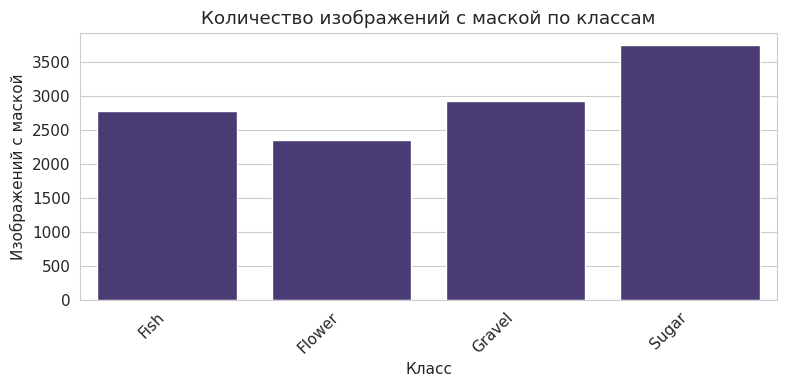

In [45]:
# 8: Загрузка и разбор train.csv
CLASSES = ['Fish', 'Flower', 'Gravel', 'Sugar']

df = pd.read_csv(TRAIN_CSV)
print(f'Всего строк: {len(df)}')
print(df.head())

df[['filename', 'class']] = df['Image_Label'].str.rsplit('_', n=1, expand=True)
print('\nУникальных изображений:', df['filename'].nunique())
print('Уникальные классы:', df['class'].unique().tolist())

class_stats = df.dropna(subset=['EncodedPixels']).groupby('class')['filename'].nunique()
class_stats_df = pd.DataFrame({
    'Класс': class_stats.index,
    'Изображений с маской': class_stats.values
})
print('\n=== Изображений с маской по классам ===')
print(class_stats_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=class_stats_df, x='Класс', y='Изображений с маской', ax=ax)
ax.set_title('Количество изображений с маской по классам')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close('all')

## 9. Формирование подвыборки

Полный датасет — 4655 изображений, на Drive, чтение медленное. Берём случайные N изображений и копируем в `/content` для ускорения последующей работы в разы.

In [46]:
# 10: Подвыборка и копирование в /content
SUBSET_SIZE = 600
SUBSET_DIR = '/content/cloud_subset'
os.makedirs(SUBSET_DIR, exist_ok=True)

files_with_mask = df.dropna(subset=['EncodedPixels'])['filename'].unique().tolist()
print(f'Изображений с хотя бы одной маской: {len(files_with_mask)}')

random.seed(42)
sample_files = random.sample(files_with_mask, min(SUBSET_SIZE, len(files_with_mask)))
print(f'Взято в подвыборку: {len(sample_files)}')

copied = 0
for f in tqdm(sample_files, desc='Копирование в /content'):
    src = os.path.join(TRAIN_IMGS_DRIVE, f)
    dst = os.path.join(SUBSET_DIR, f)
    if not os.path.exists(dst) and os.path.exists(src):
        shutil.copy2(src, dst)
        copied += 1
print(f'Скопировано новых файлов: {copied}')
print(f'Всего в папке: {len(os.listdir(SUBSET_DIR))}')

subset_df = pd.DataFrame({
    'Параметр': ['Размер подвыборки', 'Папка', 'Свободно в /content'],
    'Значение': [len(sample_files), SUBSET_DIR, f'{shutil.disk_usage("/content").free / 1e9:.1f} ГБ']
})
print('\n=== Сводка подвыборки ===')
print(subset_df.to_string(index=False))

df_subset = df[df['filename'].isin(sample_files)].copy()
print(f'\nСтрок в df_subset: {len(df_subset)}')

Изображений с хотя бы одной маской: 5546
Взято в подвыборку: 600


Копирование в /content:   0%|          | 0/600 [00:00<?, ?it/s]

Скопировано новых файлов: 0
Всего в папке: 502

=== Сводка подвыборки ===
           Параметр              Значение
  Размер подвыборки                   600
              Папка /content/cloud_subset
Свободно в /content               66.6 ГБ

Строк в df_subset: 2400


## 11. EDA: примеры изображений и масок

Декодируем RLE-маски и визуализируем три случайных изображения вместе с их каналами Fish, Flower, Gravel, Sugar.

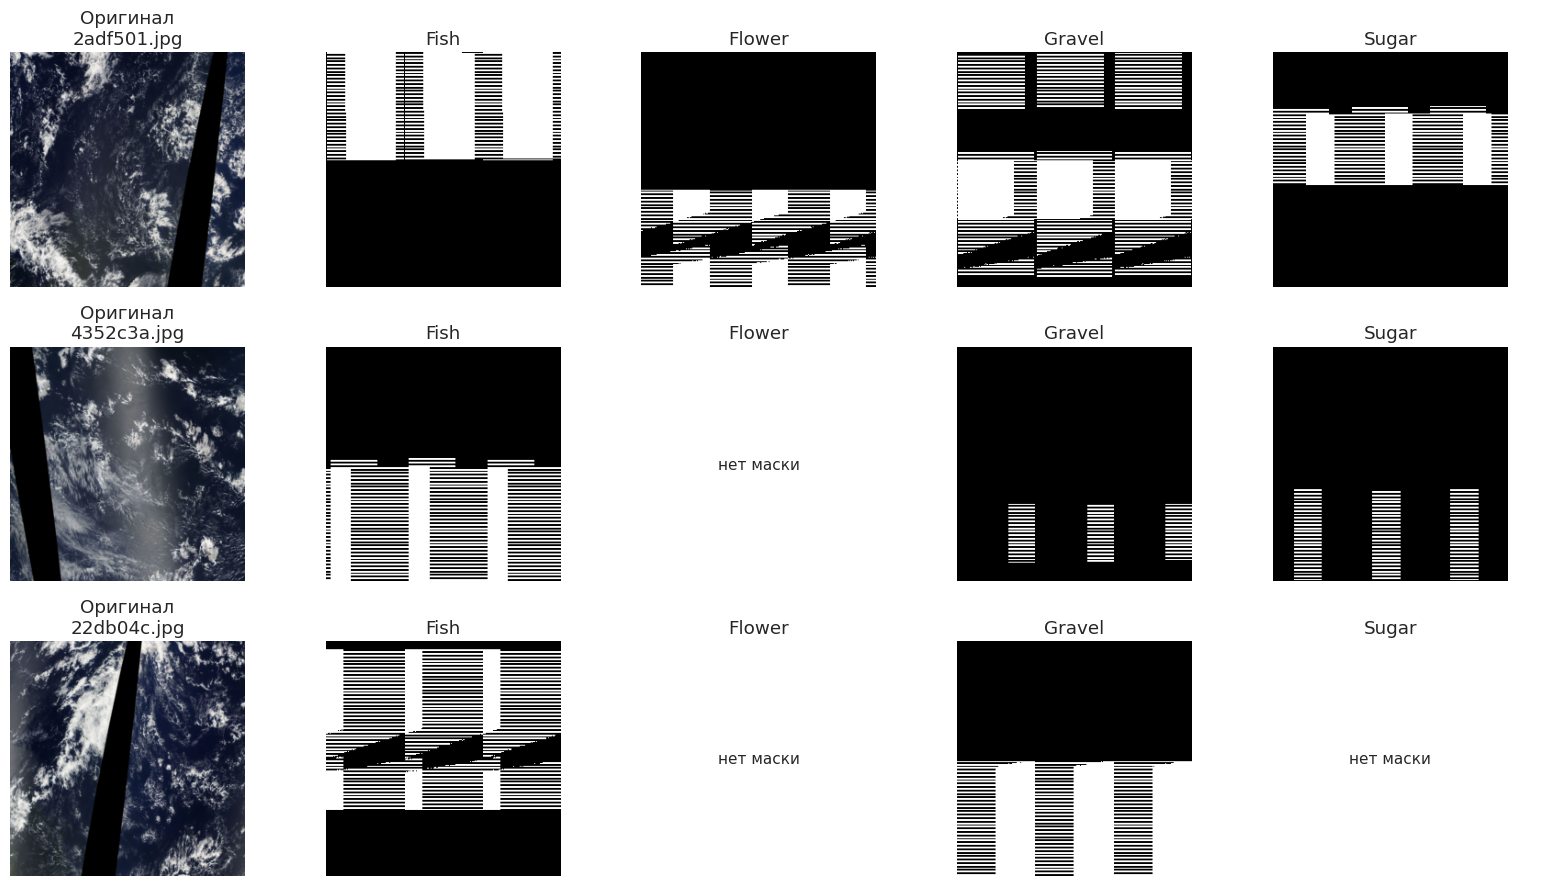

In [47]:
# 12: RLE-декодер и визуализация примеров
ORIG_H, ORIG_W = 1400, 2100

def rle_decode(mask_rle, shape=(ORIG_H, ORIG_W)):
    """Декодирует RLE-строку в бинарную маску shape=(H, W)."""
    if pd.isna(mask_rle) or mask_rle == '':
        return np.zeros(shape, dtype=np.uint8)
    s = mask_rle.split()
    starts = np.asarray(s[0::2], dtype=int) - 1
    lengths = np.asarray(s[1::2], dtype=int)
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape)

sample_show = random.sample(sample_files, 3)
fig, axes = plt.subplots(3, 5, figsize=(16, 9))

for i, fname in enumerate(sample_show):
    img = Image.open(os.path.join(SUBSET_DIR, fname)).convert('RGB')
    img_rs = img.resize((256, 256), Image.BILINEAR)
    axes[i, 0].imshow(img_rs)
    axes[i, 0].set_title(f'Оригинал\n{fname[:15]}')
    axes[i, 0].axis('off')

    for j, cls in enumerate(CLASSES):
        row = df_subset[(df_subset['filename'] == fname) & (df_subset['class'] == cls)]
        if len(row) > 0 and pd.notna(row['EncodedPixels'].values[0]):
            mask = rle_decode(row['EncodedPixels'].values[0])
            mask_rs = np.array(Image.fromarray(mask * 255).resize((256, 256), Image.NEAREST)) / 255
            axes[i, j + 1].imshow(mask_rs, cmap='gray')
        else:
            axes[i, j + 1].text(0.5, 0.5, 'нет маски', ha='center', va='center')
        axes[i, j + 1].set_title(cls)
        axes[i, j + 1].axis('off')

plt.tight_layout()
plt.show()
plt.close('all')

## 13. Выводы по EDA

**Заполнить после получения чисел:**

- Всего в датасете: `[N_TOTAL]` изображений
- В подвыборке: `[N_SUBSET]`
- Распределение классов: `[CLASS_DIST]`
- Дисбаланс: `[IMBALANCE]`
- Размер изображений (оригинал): `[IMG_SIZE_ORIG]`

## 14. Dataset и DataLoader

Загружаем изображение, ресайзим до 256×256. Маску собираем из 4 RLE-строк → 4-канальный тензор. Аугментации: случайные флипы по горизонтали и вертикали.

In [48]:
# 15: Dataset с RLE-разметкой (с проверкой целостности файлов)
class CloudDataset(Dataset):
    def __init__(self, df, img_dir, classes, img_size=256, augment=False):
        self.img_dir = img_dir
        self.classes = classes
        self.img_size = img_size
        self.augment = augment

        # Индекс: filename -> {class: rle}
        self.masks = {}
        for _, row in df.iterrows():
            fn = row['filename']
            cls = row['class']
            rle = row['EncodedPixels']
            if pd.notna(rle):
                self.masks.setdefault(fn, {})[cls] = rle

        # Фильтрация: файл должен существовать И открываться как изображение
        available = set(os.listdir(img_dir))
        candidates = [f for f in self.masks.keys() if f in available]

        valid_files = []
        corrupted = 0
        for f in tqdm(candidates, desc='Проверка целостности', leave=False):
            try:
                with Image.open(os.path.join(img_dir, f)) as im:
                    im.verify()
                valid_files.append(f)
            except Exception:
                corrupted += 1

        self.files = valid_files
        print(f'[CloudDataset] Валидных: {len(self.files)} | Битых: {corrupted} | '
              f'Нет на диске: {len(self.masks) - len(candidates)}')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img = np.array(img, dtype=np.float32) / 255.0
        img = img.transpose(2, 0, 1)

        mask = np.zeros((len(self.classes), self.img_size, self.img_size), dtype=np.float32)
        m_dict = self.masks[fname]
        for i, cls in enumerate(self.classes):
            if cls in m_dict:
                m = rle_decode(m_dict[cls])
                m_img = Image.fromarray((m * 255).astype(np.uint8))
                m_rs = np.array(m_img.resize((self.img_size, self.img_size), Image.NEAREST))
                mask[i] = (m_rs > 127).astype(np.float32)

        if self.augment:
            if random.random() < 0.5:
                img = img[:, :, ::-1].copy()
                mask = mask[:, :, ::-1].copy()
            if random.random() < 0.5:
                img = img[:, ::-1, :].copy()
                mask = mask[:, ::-1, :].copy()

        return torch.from_numpy(img), torch.from_numpy(mask)

print('CloudDataset определён (с проверкой целостности).')

CloudDataset определён (с проверкой целостности).


In [49]:
# 16: Train/Val split и DataLoader
random.seed(42)
random.shuffle(sample_files)

split = int(0.8 * len(sample_files))
train_files = sample_files[:split]
val_files = sample_files[split:]

df_train = df_subset[df_subset['filename'].isin(train_files)]
df_val = df_subset[df_subset['filename'].isin(val_files)]

IMG_SIZE = 256
BATCH_SIZE = 16

train_ds = CloudDataset(df_train, SUBSET_DIR, CLASSES, img_size=IMG_SIZE, augment=True)
val_ds = CloudDataset(df_val, SUBSET_DIR, CLASSES, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
xb, yb = next(iter(train_loader))
print(f'Батч изображений: {xb.shape}, Батч масок: {yb.shape}')

Проверка целостности:   0%|          | 0/404 [00:00<?, ?it/s]

[CloudDataset] Валидных: 404 | Битых: 0 | Нет на диске: 76


Проверка целостности:   0%|          | 0/98 [00:00<?, ?it/s]

[CloudDataset] Валидных: 97 | Битых: 1 | Нет на диске: 22
Train: 404 | Val: 97
Батч изображений: torch.Size([16, 3, 256, 256]), Батч масок: torch.Size([16, 4, 256, 256])


## 17. Архитектура U-Net

Классический энкодер-декодер с skip-connections. Выход — 4 канала (по одному на класс), логиты без сигмоиды (сигмоида применяется в функции потерь и метрике).

In [50]:
# 18: Архитектура U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=4, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 8, base * 16)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))
        return self.out(d1)

model = UNet(in_ch=3, out_ch=len(CLASSES), base=32).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net. Параметров: {n_params:,}')

U-Net. Параметров: 7,763,140


## 19. Функция потерь и метрика

BCE + Dice Loss — стандарт для сегментации: BCE даёт попиксельный сигнал, Dice оптимизирует пересечение масок и устойчив к дисбалансу классов. Метрика — Dice coefficient (по ТЗ).

In [51]:
# 20: Функции Dice coefficient и DiceBCELoss
def dice_coef(preds, targets, threshold=0.5, eps=1e-6):
    """Dice coefficient по батчу. Каналы без объектов в target исключаются из усреднения."""
    preds = (torch.sigmoid(preds) > threshold).float()
    inter = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2 * inter + eps) / (union + eps)

    has_target = (targets.sum(dim=(2, 3)) > 0).float()
    denom = has_target.sum()
    if denom == 0:
        return torch.tensor(0.0, device=preds.device)
    return (dice * has_target).sum() / denom


class DiceBCELoss(nn.Module):
    """Комбинация BCEWithLogitsLoss с pos_weight и Dice Loss."""
    def __init__(self, bce_weight=0.5, pos_weight=5.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight], dtype=torch.float32)
        )
        self.bce_weight = bce_weight

    def forward(self, preds, targets, device=None):
        if device is not None and self.bce.pos_weight.device != device:
            self.bce.pos_weight = self.bce.pos_weight.to(device)

        bce_loss = self.bce(preds, targets)

        p = torch.sigmoid(preds)
        inter = (p * targets).sum(dim=(2, 3))
        union = p.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice_per_channel = 1 - (2 * inter + 1e-6) / (union + 1e-6)

        has_target = (targets.sum(dim=(2, 3)) > 0).float()
        if has_target.sum() == 0:
            dice_loss = torch.tensor(0.0, device=preds.device)
        else:
            dice_loss = (dice_per_channel * has_target).sum() / has_target.sum()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


criterion = DiceBCELoss(bce_weight=0.5, pos_weight=5.0)
print('DiceBCELoss инициализирован.')

DiceBCELoss инициализирован.


## 21. Обучение с ранней остановкой

Оптимизатор Adam, lr=1e-3. На GPU T4 используем mixed precision (AMP) для ускорения. Early stopping по `val_dice`, patience=7, максимум 40 эпох. Лучшая модель сохраняется и восстанавливается после остановки.

In [52]:
# 22: Цикл обучения с ранней остановкой
import torch

EPOCHS, PATIENCE, LR = 50, 12, 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

use_amp = (device.type == 'cuda')
scaler = torch.amp.GradScaler('cuda') if use_amp else None

history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
best_dice, best_state, patience_counter = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tl, td = 0.0, 0.0
    for xb, yb in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        if use_amp:
            with torch.amp.autocast('cuda'):
                logits = model(xb)
                loss = criterion(logits, yb, device=device)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(xb)
            loss = criterion(logits, yb, device=device)
            loss.backward()
            optimizer.step()
        tl += loss.item() * xb.size(0)
        td += dice_coef(logits.detach(), yb).item() * xb.size(0)
    train_loss, train_dice = tl / len(train_ds), td / len(train_ds)

    model.eval()
    vl, vd = 0.0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb, device=device)
            vl += loss.item() * xb.size(0)
            vd += dice_coef(logits, yb).item() * xb.size(0)
    val_loss, val_dice = vl / len(val_ds), vd / len(val_ds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} train_dice={train_dice:.4f} | '
          f'val_loss={val_loss:.4f} val_dice={val_dice:.4f}')

    if val_dice > best_dice:
        best_dice = val_dice
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nРанняя остановка на эпохе {epoch}. Best val_dice = {best_dice:.4f}')
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f'\nЛучшая модель восстановлена. Best val_dice = {best_dice:.4f}')

Epoch 1/50:   0%|          | 0/26 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792c5b96b560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


Epoch 01 | train_loss=0.8838 train_dice=0.3644 | val_loss=0.9351 val_dice=0.2148


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792c5b96b560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x792c5b96b560>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive


Epoch 2/50:   0%|          | 0/26 [00:00<?, ?it/s]

...

Epoch 18 | train_loss=0.8347 train_dice=0.3669 | val_loss=0.9158 val_dice=0.3156


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792c5b96b560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792c5b96b560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 19/50:   0%|          | 0/26 [00:01<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792c5b96b560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x792c5b96b560>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 19 | train_loss=0.8361 train_dice=0.3658 | val_loss=0.9122 val_dice=0.3158

Ранняя остановка на эпохе 19. Best val_dice = 0.3471

Лучшая модель восстановлена. Best val_dice = 0.3471


## 23. Графики обучения

Динамика loss и Dice по эпохам. Под графиками — табличная сводка для копирования.

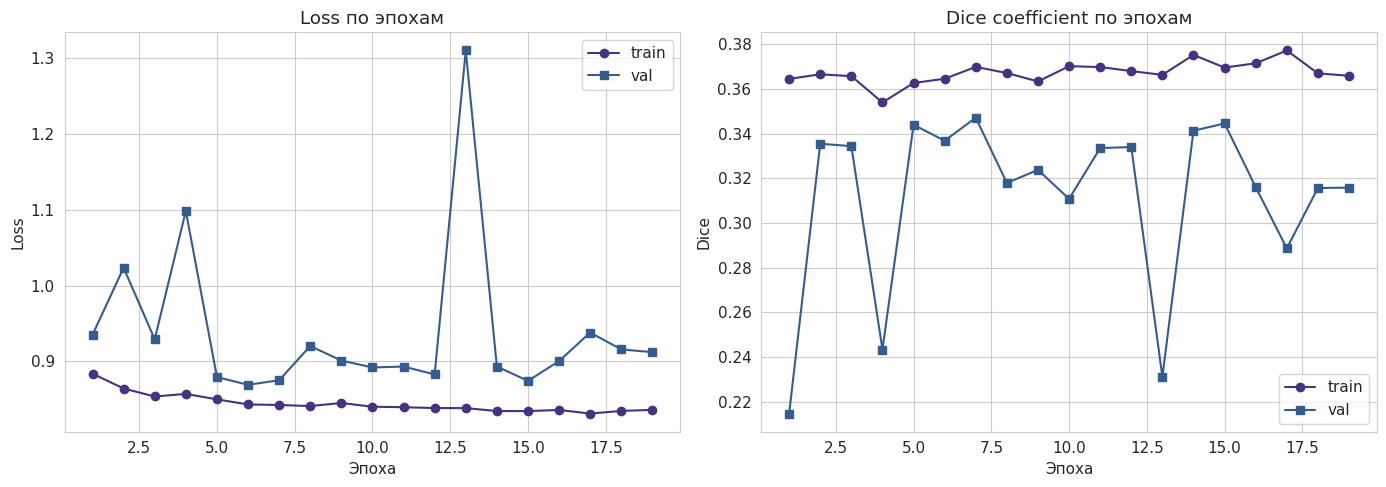

=== История обучения ===
 Эпоха train_loss val_loss train_dice val_dice
     1     0.8838   0.9351     0.3644   0.2148
     2     0.8643   1.0235     0.3665   0.3355
     3     0.8537   0.9291     0.3657   0.3343
     4     0.8572   1.0985     0.3539   0.2434
     5     0.8499   0.8793     0.3626   0.3439
     6     0.8433   0.8692     0.3645   0.3368
     7     0.8425   0.8751     0.3698   0.3471
     8     0.8411   0.9203     0.3671   0.3179
     9     0.8452   0.9011     0.3633   0.3238
    10     0.8402   0.8920     0.3701   0.3108
    11     0.8396   0.8932     0.3697   0.3335
    12     0.8385   0.8828     0.3679   0.3339
    13     0.8384   1.3101     0.3662   0.2312
    14     0.8345   0.8932     0.3751   0.3413
    15     0.8345   0.8743     0.3695   0.3445
    16     0.8360   0.9004     0.3714   0.3161
    17     0.8312   0.9381     0.3771   0.2886
    18     0.8347   0.9158     0.3669   0.3156
    19     0.8361   0.9122     0.3658   0.3158


In [53]:
# 24: Графики обучения и числовая сводка
ep = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, history['train_loss'], label='train', marker='o')
axes[0].plot(ep, history['val_loss'], label='val', marker='s')
axes[0].set_title('Loss по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(ep, history['train_dice'], label='train', marker='o')
axes[1].plot(ep, history['val_dice'], label='val', marker='s')
axes[1].set_title('Dice coefficient по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Dice')
axes[1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

hist_df = pd.DataFrame({
    'Эпоха': list(ep),
    'train_loss': [f'{v:.4f}' for v in history['train_loss']],
    'val_loss': [f'{v:.4f}' for v in history['val_loss']],
    'train_dice': [f'{v:.4f}' for v in history['train_dice']],
    'val_dice': [f'{v:.4f}' for v in history['val_dice']],
})
print('=== История обучения ===')
print(hist_df.to_string(index=False))

## 25. Оценка Dice по классам на валидации

Считаем Dice отдельно для каждого класса, а также средний. Это показывает, на каких классах модель работает хуже.

=== Dice по классам (порог = 0.3) ===
 Класс   Dice
  Fish 0.4279
Flower 0.5153
Gravel 0.4357
 Sugar 0.3924

Средний Dice: 0.4428


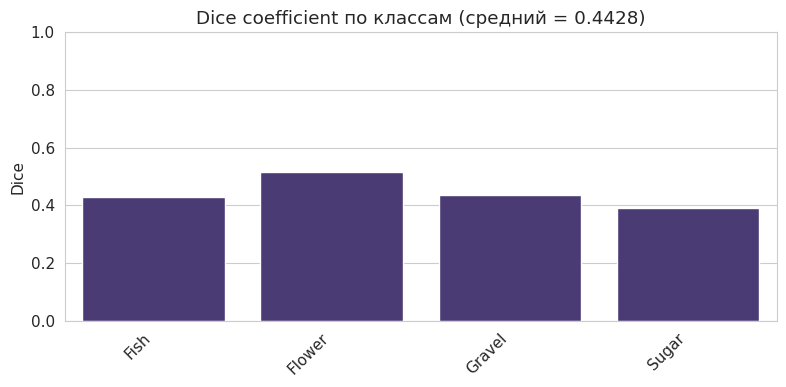

In [54]:
# 26: Оценка Dice по классам на валидации
model.eval()
THRESHOLD = 0.3

all_p, all_t = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        preds = (torch.sigmoid(model(xb)) > THRESHOLD).float().cpu()
        all_p.append(preds)
        all_t.append(yb)
all_p = torch.cat(all_p)
all_t = torch.cat(all_t)

dice_per_class = {}
for i, cls in enumerate(CLASSES):
    p, t = all_p[:, i], all_t[:, i]
    has_target = t.sum(dim=(1, 2)) > 0
    if has_target.sum() == 0:
        dice_per_class[cls] = 0.0
        continue
    p_, t_ = p[has_target], t[has_target]
    inter = (p_ * t_).sum().item()
    union = p_.sum().item() + t_.sum().item()
    dice_per_class[cls] = (2 * inter + 1e-6) / (union + 1e-6)

MEAN_DICE = float(np.mean(list(dice_per_class.values())))

dice_df = pd.DataFrame({
    'Класс': list(dice_per_class.keys()),
    'Dice': [f'{v:.4f}' for v in dice_per_class.values()]
})
print(f'=== Dice по классам (порог = {THRESHOLD}) ===')
print(dice_df.to_string(index=False))
print(f'\nСредний Dice: {MEAN_DICE:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=list(dice_per_class.keys()), y=list(dice_per_class.values()), ax=ax)
ax.set_title(f'Dice coefficient по классам (средний = {MEAN_DICE:.4f})')
ax.set_ylabel('Dice')
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close('all')

DICE_FISH = dice_per_class['Fish']
DICE_FLOWER = dice_per_class['Flower']
DICE_GRAVEL = dice_per_class['Gravel']
DICE_SUGAR = dice_per_class['Sugar']
BEST_VAL_DICE = best_dice
N_EPOCHS_RUN = len(history['train_loss'])

## 27. Визуализация предсказаний

Сравниваем на валидационных примерах: оригинал, ground truth, предсказание модели. Даёт качественное представление о работе сети.

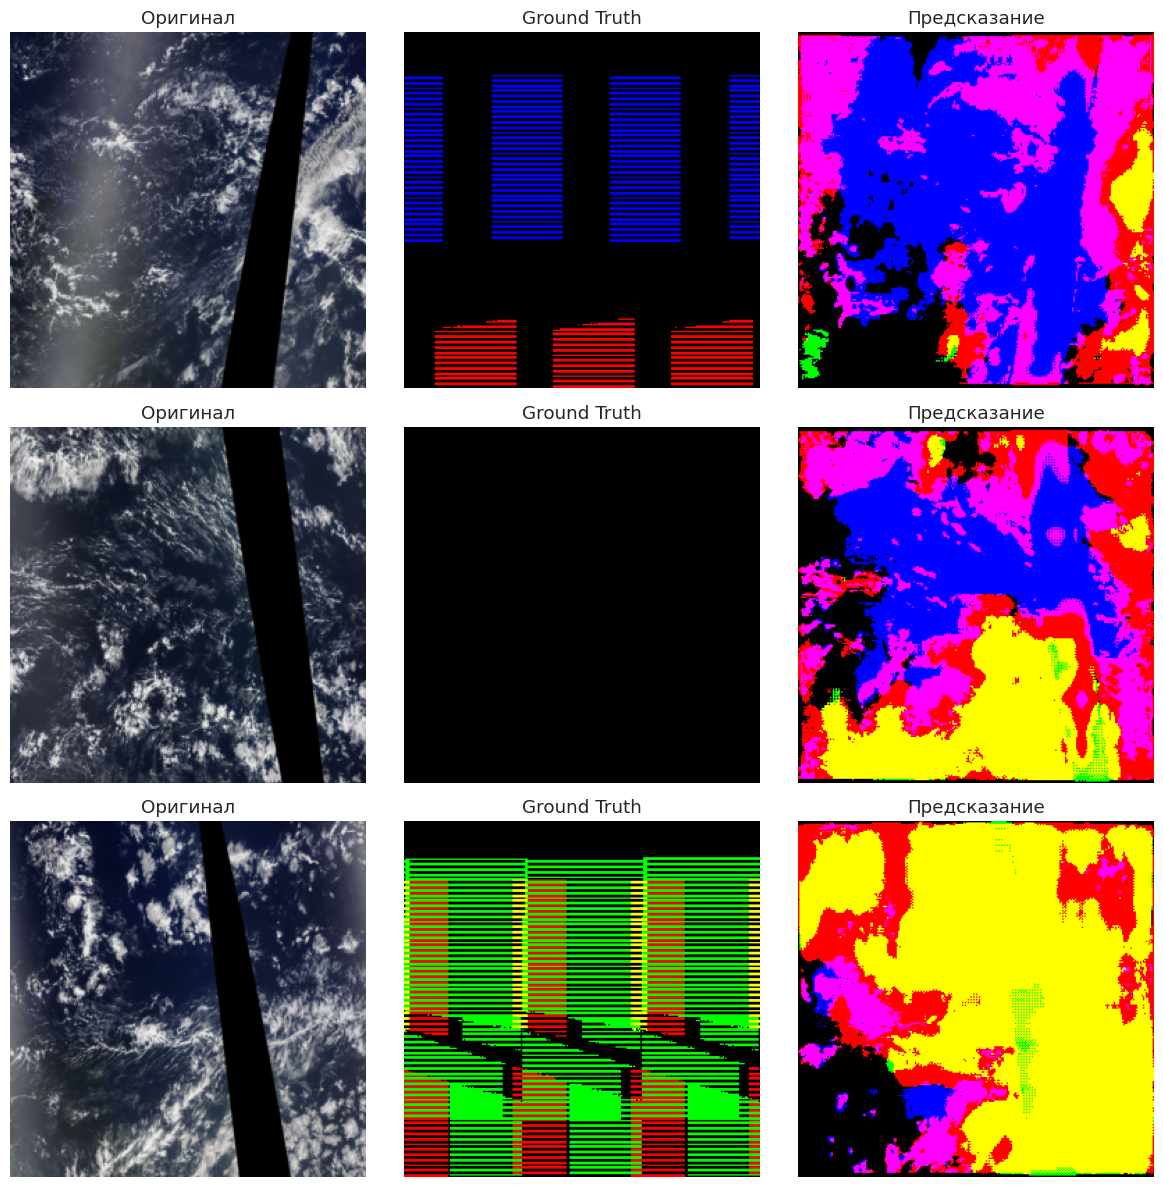

In [55]:
# 28: Визуализация предсказаний модели
model.eval()
n_show = 3
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))

with torch.no_grad():
    for i in range(n_show):
        xb, yb = val_ds[i]
        pred = (torch.sigmoid(model(xb.unsqueeze(0).to(device))) > 0.5).float().cpu().squeeze(0)

        axes[i, 0].imshow(xb.permute(1, 2, 0).numpy())
        axes[i, 0].set_title('Оригинал')
        axes[i, 0].axis('off')

        gt = yb.permute(1, 2, 0).numpy()
        axes[i, 1].imshow(gt[:, :, :3] if gt.shape[2] >= 3 else gt[:, :, 0], cmap=None)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        pr = pred.permute(1, 2, 0).numpy()
        axes[i, 2].imshow(pr[:, :, :3] if pr.shape[2] >= 3 else pr[:, :, 0], cmap=None)
        axes[i, 2].set_title('Предсказание')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
plt.close('all')

## 29. Выводы

**Заполнить после получения чисел:**

- Лучший val_dice: `[BEST_VAL_DICE]` на эпохе `[N_EPOCHS_RUN]`
- Средний Dice на валидации: `[MEAN_DICE]`
- По классам: Fish = `[DICE_FISH]`, Flower = `[DICE_FLOWER]`, Gravel = `[DICE_GRAVEL]`, Sugar = `[DICE_SUGAR]`
- Наблюдения по графику обучения: `[TRAIN_OBS]`
- Слабые классы: `[WEAK_CLASS]`
- Возможные улучшения: `[IMPROVEMENTS]`

In [56]:
# 30: Финальная сводка для передачи данных
final_summary = pd.DataFrame({
    'Параметр': [
        'Размер подвыборки', 'Train / Val', 'Эпох обучено',
        'Лучший val_dice', 'Средний Dice (val)',
        'Dice Fish', 'Dice Flower', 'Dice Gravel', 'Dice Sugar',
        'Размер изображений', 'Batch size',
    ],
    'Значение': [
        len(sample_files),
        f'{len(train_ds)} / {len(val_ds)}',
        N_EPOCHS_RUN,
        f'{BEST_VAL_DICE:.4f}',
        f'{MEAN_DICE:.4f}',
        f'{DICE_FISH:.4f}',
        f'{DICE_FLOWER:.4f}',
        f'{DICE_GRAVEL:.4f}',
        f'{DICE_SUGAR:.4f}',
        f'{IMG_SIZE}x{IMG_SIZE}',
        BATCH_SIZE,
    ]
})
print('=== Финальная сводка ===')
print(final_summary.to_string(index=False))

=== Финальная сводка ===
          Параметр Значение
 Размер подвыборки      600
       Train / Val 404 / 97
      Эпох обучено       19
   Лучший val_dice   0.3471
Средний Dice (val)   0.4428
         Dice Fish   0.4279
       Dice Flower   0.5153
       Dice Gravel   0.4357
        Dice Sugar   0.3924
Размер изображений  256x256
        Batch size       16
